In [82]:
import numpy as np  
import pandas as pd
import sys
import os

units_line = "- - - Wm-2 Wm-2 K g/kg hPa mm/day mm/day m/s ppm per-mill per-mill mg/m2/day mg/m2/day mg/m2/day -"
export_dir_forcing = "/Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0_LAI/transient"

In [ ]:
root_dir_forcing = "/Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0/transient"
forcing_paths = []

for root, dirs, files in os.walk(root_dir_forcing):
    for name in files:
        full_path = os.path.join(root, name)
        forcing_paths.append(full_path)

In [27]:
root_dir_lai = "/Net/Groups/BSI/work_scratch/ppapastefanou/LAI_kai"
lai_paths = []

for root, dirs, files in os.walk(root_dir_lai):
    for name in files:
        full_path = os.path.join(root, name)
        lai_paths.append(full_path)

In [14]:
# 1. Helper function to extract the site ID (e.g., "BE-Lon") from the path
def extract_id(filepath):
    filename = filepath.split('/')[-1] # Gets "BE-Lon_LAI_processing.csv"
    site_id = filename.split('_')[0]   # Gets "BE-Lon"
    return site_id

# 2. Create sets of the IDs for fast comparison
ids_folder1 = {extract_id(path) for path in lai_paths}
ids_folder2 = {extract_id(path) for path in forcing_paths}

# 3. Find the exact overlap (intersection) of the IDs
common_ids = ids_folder1.intersection(ids_folder2)
print(f"Overlapping IDs: {common_ids}")

# 4. (Optional) Get the original file paths that match the overlapping IDs
matched_paths_folder1 = [p for p in lai_paths if extract_id(p) in common_ids]
matched_paths_folder2 = [p for p in forcing_paths if extract_id(p) in common_ids]


Overlapping IDs: {'DE-RuS', 'US-Ro1', 'US-ARM', 'US-CS4', 'CZ-KrP', 'US-CS1', 'DE-Geb', 'US-Tw3', 'DK-Vng', 'DE-Kli', 'US-Bi2', 'US-Ro5', 'US-CS3', 'FR-Lam', 'BE-Lon', 'IT-BCi', 'FR-Aur', 'CH-Oe2', 'IT-CA2', 'US-Bi1', 'US-CRT', 'FR-Gri', 'US-Ro6'}


In [22]:
common_id_list = list(common_ids)

In [28]:
id = common_id_list[1]

In [58]:
forcing_file_path = f"{root_dir_forcing}/{id}_t_1901-2021.dat"
forcing_file = pd.read_csv(forcing_file_path, sep=r'\s+', skiprows=[1])

In [53]:
forcing_file

,year,doy,hour,swvis_srf_down,lw_srf_down,t_air,q_air,press_srf,rain,snow,wind_air,co2_mixing_ratio,co2_dC13,co2DC14,nhx_srf_down,noy_srf_down,p_srf_down,time,LAI_x,LAI_y
0,1901,1,0.0,0.0060,206.8900,257.9840,0.8929,972.0100,0.0,0.0,7.5010,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 00:00:00,NaN,NaN
1,1901,1,0.5,0.0030,210.4200,257.3330,0.8706,972.5000,0.0,0.0,7.1790,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 00:30:00,NaN,NaN
2,1901,1,1.0,0.0060,203.4900,256.9180,0.8681,972.6500,0.0,0.0,6.8200,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 01:00:00,NaN,NaN
3,1901,1,1.5,0.0000,216.4600,256.7440,0.8696,972.3800,0.0,0.0,6.9180,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 01:30:00,NaN,NaN
4,1901,1,2.0,0.0000,199.2600,256.3610,0.7643,972.2300,0.0,0.0,7.6610,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 02:00:00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119915,2021,365,21.5,0.1037,196.5097,257.6101,0.9686,982.5619,0.0,0.0,2.6743,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 21:30:00,0.386249,0.386249
2119916,2021,365,22.0,0.1037,184.2896,256.7958,0.8931,983.8390,0.0,0.0,2.6421,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 22:00:00,0.386249,0.386249
2119917,2021,365,22.5,0.1037,184.2896,256.7958,0.8931,983.8390,0.0,0.0,2.6421,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 22:30:00,0.386249,0.386249
2119918,2021,365,23.0,0.1037,205.1394,256.4218,0.8343,984.8250,0.0,0.0,3.2822,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 23:00:00,0.386249,0.386249


In [47]:
lai_file_path = f"{root_dir_lai}/{id}_LAI_processing.csv"
lai_file = pd.read_csv(lai_file_path)
lai_file['time'] = pd.to_datetime(lai_file['time'])


In [48]:
lai_file

,time,LAI
0,1990-01-01 00:00:00,0.369728
1,1990-01-01 00:30:00,0.369724
2,1990-01-01 01:00:00,0.369720
3,1990-01-01 01:30:00,0.369716
4,1990-01-01 02:00:00,0.369713
...,...,...
561019,2021-12-31 21:30:00,0.386249
561020,2021-12-31 22:00:00,0.386249
561021,2021-12-31 22:30:00,0.386249
561022,2021-12-31 23:00:00,0.386249


In [59]:
# 1. Create a base date from the 'year' and 'doy'
# The format '%Y %j' tells Pandas to expect a 4-digit year and a 1-3 digit Day of Year
base_date = pd.to_datetime(
    forcing_file['year'].astype(str) + ' ' + forcing_file['doy'].astype(str), 
    format='%Y %j'
)

# 2. Convert the float 'hour' column (0.0, 0.5, 1.0) into a time delta
# Pandas is smart enough to turn 0.5 hours into 30 minutes automatically!
time_addition = pd.to_timedelta(forcing_file['hour'], unit='h')

# 3. Add them together to create the new 'time' column
forcing_file['time'] = base_date + time_addition
# 4. Merge them togehter
forcing_file_new = pd.merge(
    forcing_file, 
    lai_file[['time', 'LAI']], # We only need to bring over time and LAI, not the whole dataframe
    on='time', 
    how='left'
)

In [60]:
forcing_file_new

,year,doy,hour,swvis_srf_down,lw_srf_down,t_air,q_air,press_srf,rain,snow,wind_air,co2_mixing_ratio,co2_dC13,co2DC14,nhx_srf_down,noy_srf_down,p_srf_down,time,LAI
0,1901,1,0.0,0.0060,206.8900,257.9840,0.8929,972.0100,0.0,0.0,7.5010,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 00:00:00,NaN
1,1901,1,0.5,0.0030,210.4200,257.3330,0.8706,972.5000,0.0,0.0,7.1790,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 00:30:00,NaN
2,1901,1,1.0,0.0060,203.4900,256.9180,0.8681,972.6500,0.0,0.0,6.8200,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 01:00:00,NaN
3,1901,1,1.5,0.0000,216.4600,256.7440,0.8696,972.3800,0.0,0.0,6.9180,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 01:30:00,NaN
4,1901,1,2.0,0.0000,199.2600,256.3610,0.7643,972.2300,0.0,0.0,7.6610,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 02:00:00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119915,2021,365,21.5,0.1037,196.5097,257.6101,0.9686,982.5619,0.0,0.0,2.6743,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 21:30:00,0.386249
2119916,2021,365,22.0,0.1037,184.2896,256.7958,0.8931,983.8390,0.0,0.0,2.6421,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 22:00:00,0.386249
2119917,2021,365,22.5,0.1037,184.2896,256.7958,0.8931,983.8390,0.0,0.0,2.6421,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 22:30:00,0.386249
2119918,2021,365,23.0,0.1037,205.1394,256.4218,0.8343,984.8250,0.0,0.0,3.2822,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 23:00:00,0.386249


In [62]:
# 1. Identify which years have LAI data and which are missing
valid_years = forcing_file_new.dropna(subset=['LAI'])['year'].unique()
missing_years = forcing_file_new[forcing_file_new['LAI'].isna()]['year'].unique()

In [65]:
# 2. Create a mapping: assign a random valid year to each missing year
# (Using a seed ensures you get the same random assignment if you rerun the code)
np.random.seed(42) 
year_mapping = {my: np.random.choice(valid_years) for my in missing_years}

In [67]:
print("Year Mapping (Missing Year -> Random Valid Year):")
for my, vy in list(year_mapping.items())[:5]:
    print(f"{my} -> {vy}")
print("...\n")

Year Mapping (Missing Year -> Random Valid Year):
1901 -> 1996
1902 -> 2009
1903 -> 2018
1904 -> 2004
1905 -> 2000
...



In [69]:
# 3. Create a temporary dataframe with all the replacement data
replacement_rows = []
for missing_year, target_valid_year in year_mapping.items():
    # Grab the DOY, Hour, and LAI for the randomly selected valid year
    source_data = forcing_file_new[forcing_file_new['year'] == target_valid_year][['doy', 'hour', 'LAI']].copy()
    
    # Change the year tag to the missing year so it aligns properly
    source_data['year'] = missing_year 
    replacement_rows.append(source_data)

In [72]:
# Combine all replacement rows into one dataframe
replacement_df = pd.concat(replacement_rows)

# 4. Use indices to align everything perfectly and update
# Setting the index to Year, DOY, and Hour guarantees the data drops into the exact right row
forcing_file_new.set_index(['year', 'doy', 'hour'], inplace=True)
replacement_df.set_index(['year', 'doy', 'hour'], inplace=True)

# The .update() function fills in the NaNs in forcing_file using the matching indices in replacement_df
forcing_file_new.update(replacement_df)

# Reset the index to turn Year, DOY, and Hour back into normal columns
forcing_file_new.reset_index(inplace=True)

# 5. Fix the Leap Year Edge Case!
# If a missing year was a leap year (366 days) but it pulled data from a non-leap year (365 days),
# DOY 366 will still be NaN. We can fill those rare gaps by carrying the previous value forward.
forcing_file_new['LAI'] = forcing_file_new['LAI'].ffill()

In [73]:
forcing_file_new

,year,doy,hour,swvis_srf_down,lw_srf_down,t_air,q_air,press_srf,rain,snow,wind_air,co2_mixing_ratio,co2_dC13,co2DC14,nhx_srf_down,noy_srf_down,p_srf_down,time,LAI
0,1901,1,0.0,0.0060,206.8900,257.9840,0.8929,972.0100,0.0,0.0,7.5010,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 00:00:00,0.376756
1,1901,1,0.5,0.0030,210.4200,257.3330,0.8706,972.5000,0.0,0.0,7.1790,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 00:30:00,0.376698
2,1901,1,1.0,0.0060,203.4900,256.9180,0.8681,972.6500,0.0,0.0,6.8200,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 01:00:00,0.376640
3,1901,1,1.5,0.0000,216.4600,256.7440,0.8696,972.3800,0.0,0.0,6.9180,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 01:30:00,0.376582
4,1901,1,2.0,0.0000,199.2600,256.3610,0.7643,972.2300,0.0,0.0,7.6610,390.03,-8.33,36.5,18.7272,12.9452,0.0046,1901-01-01 02:00:00,0.376524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119915,2021,365,21.5,0.1037,196.5097,257.6101,0.9686,982.5619,0.0,0.0,2.6743,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 21:30:00,0.386249
2119916,2021,365,22.0,0.1037,184.2896,256.7958,0.8931,983.8390,0.0,0.0,2.6421,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 22:00:00,0.386249
2119917,2021,365,22.5,0.1037,184.2896,256.7958,0.8931,983.8390,0.0,0.0,2.6421,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 22:30:00,0.386249
2119918,2021,365,23.0,0.1037,205.1394,256.4218,0.8343,984.8250,0.0,0.0,3.2822,414.26,-8.60,-15.1,20.8896,10.7853,0.0046,2021-12-31 23:00:00,0.386249


In [74]:
import matplotlib.pyplot as plt

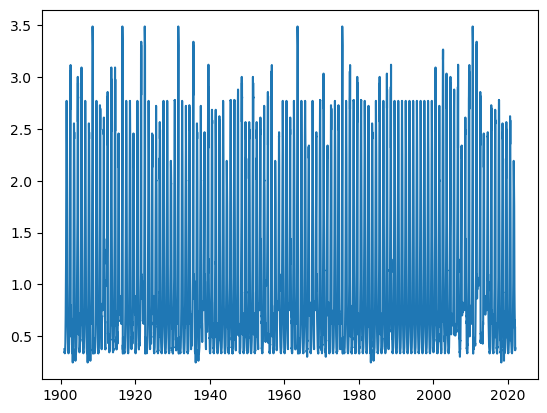

In [76]:
plt.plot(forcing_file_new["time"],forcing_file_new["LAI"])

In [ ]:
# 1. Drop the 'time' column before exporting
final_output = forcing_file_new.drop(columns=['time'])

output_file = f"{export_dir_forcing}/{id}_t_1901-2021.dat"

# 2. Export the data
# sep=' ' sets the delimiter to a single whitespace
# index=False ensures Pandas doesn't write the row numbers into the file
# 4. Write the file in stages
with open(output_file, 'w') as f:
    # Write the column names (header)
    f.write(' '.join(final_output.columns) + '\n')
    
    # Write your custom units line
    f.write(units_line + '\n')
    
    # Append the actual data without a header
    final_output.to_csv(f, sep=' ', index=False, header=False)

print(f"File exported successfully to {output_file}")

File exported successfully to /Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0_LAI/transient/US-Ro1_t_1901-2021.dat


In [84]:
for id in common_id_list:
    forcing_file_path = f"{root_dir_forcing}/{id}_t_1901-2021.dat"
    forcing_file = pd.read_csv(forcing_file_path, sep=r'\s+', skiprows=[1])

    lai_file_path = f"{root_dir_lai}/{id}_LAI_processing.csv"
    lai_file = pd.read_csv(lai_file_path)
    lai_file['time'] = pd.to_datetime(lai_file['time'])

    # 1. Create a base date from the 'year' and 'doy'
    # The format '%Y %j' tells Pandas to expect a 4-digit year and a 1-3 digit Day of Year
    base_date = pd.to_datetime(
        forcing_file['year'].astype(str) + ' ' + forcing_file['doy'].astype(str), 
        format='%Y %j'
    )

    # 2. Convert the float 'hour' column (0.0, 0.5, 1.0) into a time delta
    # Pandas is smart enough to turn 0.5 hours into 30 minutes automatically!
    time_addition = pd.to_timedelta(forcing_file['hour'], unit='h')

    # 3. Add them together to create the new 'time' column
    forcing_file['time'] = base_date + time_addition
    # 4. Merge them togehter
    forcing_file_new = pd.merge(
        forcing_file, 
        lai_file[['time', 'LAI']], # We only need to bring over time and LAI, not the whole dataframe
        on='time', 
        how='left'
    )
    # 1. Identify which years have LAI data and which are missing
    valid_years = forcing_file_new.dropna(subset=['LAI'])['year'].unique()
    missing_years = forcing_file_new[forcing_file_new['LAI'].isna()]['year'].unique()
    np.random.seed(42) 
    year_mapping = {my: np.random.choice(valid_years) for my in missing_years}
    print("Year Mapping (Missing Year -> Random Valid Year):")
    for my, vy in list(year_mapping.items())[:5]:
        print(f"{my} -> {vy}")
    print("...\n")

    replacement_rows = []
    for missing_year, target_valid_year in year_mapping.items():
        # Grab the DOY, Hour, and LAI for the randomly selected valid year
        source_data = forcing_file_new[forcing_file_new['year'] == target_valid_year][['doy', 'hour', 'LAI']].copy()
        
        # Change the year tag to the missing year so it aligns properly
        source_data['year'] = missing_year 
        replacement_rows.append(source_data)
        
    # Combine all replacement rows into one dataframe
    replacement_df = pd.concat(replacement_rows)

    # 4. Use indices to align everything perfectly and update
    # Setting the index to Year, DOY, and Hour guarantees the data drops into the exact right row
    forcing_file_new.set_index(['year', 'doy', 'hour'], inplace=True)
    replacement_df.set_index(['year', 'doy', 'hour'], inplace=True)

    # The .update() function fills in the NaNs in forcing_file using the matching indices in replacement_df
    forcing_file_new.update(replacement_df)

    # Reset the index to turn Year, DOY, and Hour back into normal columns
    forcing_file_new.reset_index(inplace=True)

    # 5. Fix the Leap Year Edge Case!
    # If a missing year was a leap year (366 days) but it pulled data from a non-leap year (365 days),
    # DOY 366 will still be NaN. We can fill those rare gaps by carrying the previous value forward.
    forcing_file_new['LAI'] = forcing_file_new['LAI'].ffill()


    plt.plot(forcing_file_new["time"],forcing_file_new["LAI"])
    plt.savefig(f"{export_dir_forcing}/{id}.png")
    plt.close()
    
    # 1. Drop the 'time' column before exporting
    final_output = forcing_file_new.drop(columns=['time'])
    output_file = f"{export_dir_forcing}/{id}_t_1901-2021.dat"

    # 2. Export the data
    # sep=' ' sets the delimiter to a single whitespace
    # index=False ensures Pandas doesn't write the row numbers into the file
    # 4. Write the file in stages
    with open(output_file, 'w') as f:
        # Write the column names (header)
        f.write(' '.join(final_output.columns) + '\n')
        
        # Write your custom units line
        f.write(units_line + '\n')
        
        # Append the actual data without a header
        final_output.to_csv(f, sep=' ', index=False, header=False)

    print(f"File exported successfully to {output_file}")

Year Mapping (Missing Year -> Random Valid Year):
1901 -> 1996
1902 -> 2009
1903 -> 2018
1904 -> 2004
1905 -> 2000
...

File exported successfully to /Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0_LAI/transient/DE-RuS_t_1901-2021.dat
Year Mapping (Missing Year -> Random Valid Year):
1901 -> 1996
1902 -> 2009
1903 -> 2018
1904 -> 2004
1905 -> 2000
...

File exported successfully to /Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0_LAI/transient/US-Ro1_t_1901-2021.dat
Year Mapping (Missing Year -> Random Valid Year):
1901 -> 1996
1902 -> 2009
1903 -> 2018
1904 -> 2004
1905 -> 2000
...

File exported successfully to /Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0_LAI/transient/US-ARM_t_1901-2021.dat
Year Mapping (Missing Year -> Random Valid Year):
1901 -> 1996
1902 -> 2009
1903 -> 2018
1904 -> 2004
1905 -> 2000
...

File exported successfully to /Net/Groups/BSI/work_scratch/ppapastefanou/quincy_fluxet22_1.0_LAI/transient/US-CS4_t_1901-2021.dat


In [89]:
final_output.shape[0]/365/24/2

121.0